In [ ]:
''' THIS IS A PLACE HOLDER /NOT REALLY/ BUT WORKS FOR THAT '''

In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/c  ontent/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
ℹ️ Drive already mounted or running locally.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1 (HISTÓRICA RECONSTRUIDA): INGESTA Y FEATURE ENGINEERING BÁSICO
# ==============================================================================
# Purpose: Reconstituir df_campaign y el Quality Index para el flujo histórico.
# ==============================================================================

if 'db_engine' in locals():
    print("--- 1. INGESTA Y PREPARACIÓN DEL CAMPO DE BATALLA (HISTÓRICA) ---")

    # 1.1. QUERY UNIFICADO (Incluyendo las columnas necesarias para el flujo posterior)
    query_campaign = """
    SELECT
        o.offer_id,
        o.session_fk,
        o.upfront_fare,
        o.est_trip_time_sec,
        o.time_to_pickup_sec,
        o.offer_timestamp,
        oa.offer_action_description as offer_action,
        pc.category_name as product_category,
        ef.eph_operational as eph_real
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
    WHERE ef.eph_operational IS NOT NULL
    """

    try:
        df_campaign = pd.read_sql_query(query_campaign, db_engine)
        print(f"✅ Ingesta completa: {len(df_campaign)} ofertas cargadas.")

        # 1.2. FEATURE ENGINEERING BÁSICO
        df_campaign['offer_timestamp'] = pd.to_datetime(df_campaign['offer_timestamp'])

        def simplify_category(cat):
            if pd.isna(cat): return 'Other'
            cat = cat.lower()
            if 'uberx' in cat: return 'UberX'
            elif 'comfort' in cat or 'business' in cat: return 'Mid-Tier'
            elif 'black' in cat: return 'Black'
            return 'Other'

        df_campaign['simplified_category'] = df_campaign['product_category'].apply(simplify_category)
        df_campaign = df_campaign[df_campaign['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])].copy()

        # 1.3. NORMALIZACIÓN (Cálculo del Índice de Calidad)
        global_anchors = df_campaign.groupby('simplified_category')['eph_real'].median().to_dict()
        df_campaign['offer_quality_index'] = df_campaign.apply(lambda row: row['eph_real'] / global_anchors.get(row['simplified_category'], 1), axis=1)

        # 1.4. DEFINICIÓN DE NIVELES Y ESTADOS (Necesario para el flujo original, aunque lo deprecaremos)
        df_campaign['is_success'] = (df_campaign['offer_quality_index'] >= 1.0).astype(int)

        print("\n--- SISTEMA LISTO PARA CELDAS ANTIGUAS ---")

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante la ingesta de la campaña: {e}")

--- 1. INGESTA Y PREPARACIÓN DEL CAMPO DE BATALLA (HISTÓRICA) ---
✅ Ingesta completa: 4750 ofertas cargadas.

--- SISTEMA LISTO PARA CELDAS ANTIGUAS ---


--- CALCULANDO EL TIEMPO ENTRE OFERTAS (DELTA) ---
📈 Tiempo de Espera Típico (Mediana): 22.00 segundos
📈 Tiempo de Espera Promedio (Media): 125.45 segundos


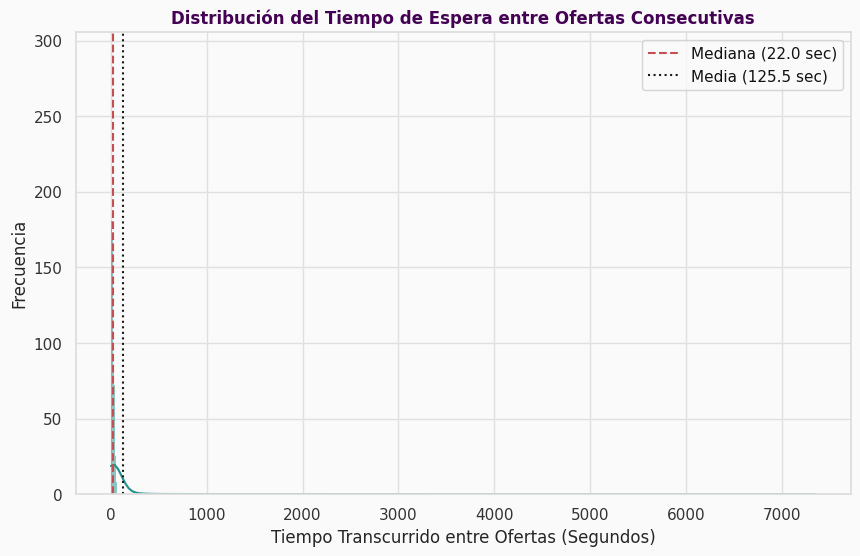

In [ ]:
# ==============================================================================
# CELL 1.5: ANÁLISIS DEL TIEMPO ENTRE OFERTAS (CÁLCULO DEL DELTA)
# ==============================================================================
# Purpose: Calcular el tiempo transcurrido (delta_sec) entre ofertas consecutivas
#          por sesión para establecer un umbral robusto para Hot/Cold Market.
# ==============================================================================

if 'df_campaign' in locals() and not df_campaign.empty:

    print("--- CALCULANDO EL TIEMPO ENTRE OFERTAS (DELTA) ---")

    # Aseguramos que los datos estén ordenados por tiempo dentro de cada sesión
    df_campaign.sort_values(by=['session_fk', 'offer_timestamp'], inplace=True)

    # 1. CALCULAR EL DELTA
    # Calculamos la diferencia entre el timestamp actual y el anterior dentro de cada grupo (session_fk)
    df_campaign['previous_timestamp'] = df_campaign.groupby('session_fk')['offer_timestamp'].shift(1)
    df_campaign['delta_time'] = (df_campaign['offer_timestamp'] - df_campaign['previous_timestamp']).dt.total_seconds()

    # La primera oferta de cada sesión tendrá NaN en 'delta_time', las ignoramos para el cálculo del umbral.
    df_deltas = df_campaign.dropna(subset=['delta_time'])

    # 2. ANÁLISIS ESTADÍSTICO DEL DELTA
    global_median_delta = df_deltas['delta_time'].median()
    global_mean_delta = df_deltas['delta_time'].mean()

    print(f"📈 Tiempo de Espera Típico (Mediana): {global_median_delta:.2f} segundos")
    print(f"📈 Tiempo de Espera Promedio (Media): {global_mean_delta:.2f} segundos")

    # 3. VISUALIZACIÓN DE LA DISTRIBUCIÓN
    plt.figure(figsize=(10, 6))
    # Usamos un límite de bins para evitar que outliers extremos distorsionen la gráfica
    sns.histplot(df_deltas['delta_time'], bins=50, kde=True, color=OPUS_TEAL, binrange=(0, 60))
    plt.axvline(x=global_median_delta, color='r', linestyle='--', label=f'Mediana ({global_median_delta:.1f} sec)')
    plt.axvline(x=global_mean_delta, color='k', linestyle=':', label=f'Media ({global_mean_delta:.1f} sec)')
    plt.title('Distribución del Tiempo de Espera entre Ofertas Consecutivas', color=OPUS_PURPLE)
    plt.xlabel('Tiempo Transcurrido entre Ofertas (Segundos)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

    # Guardamos la métrica en el DataFrame original (usando 0 para el primer valor de la sesión)
    df_campaign['delta_time_sec'] = df_campaign['delta_time'].fillna(0)

    # Transferimos para la siguiente celda
    global df_opportunity_cost
    df_opportunity_cost = df_campaign

else:
    print("🔴 Ejecutar Celda 1 primero para cargar `df_campaign`.")

--- Análisis de Ritmo de Sesión ---
P25 (Ritmo Rápido): 20.00 segundos entre ofertas (Umbral sugerido para Hot)
P50 (Ritmo Típico): 22.00 segundos entre ofertas
P75 (Ritmo Lento): 26.00 segundos entre ofertas (Umbral sugerido para Cold)


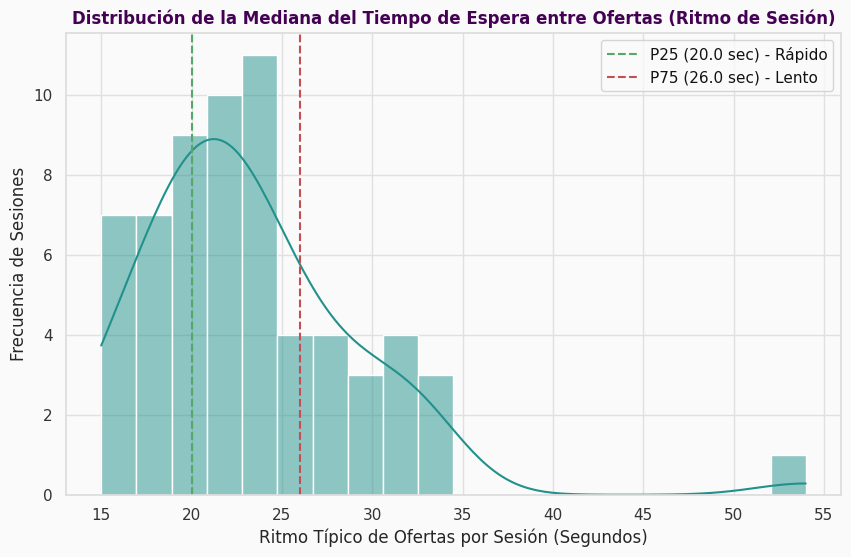

In [ ]:
# ==============================================================================
# CELL 1.6 (TEMPORAL): DISTRIBUCIÓN DEL RITMO DE OFERTAS POR SESIÓN
# ==============================================================================
# Purpose: Calcular el delta de tiempo de ofertas a nivel de sesión para
#          establecer un umbral de Hot/Cold basado en el ritmo operativo.
# ==============================================================================

if 'df_opportunity_cost' in locals():

    # Aseguramos que solo usamos deltas válidos (no el 0 inicial)
    df_deltas_valid = df_opportunity_cost[df_opportunity_cost['delta_time_sec'] > 0].copy()

    # 1. CALCULAR EL RITMO TÍPICO (MEDIANA) POR SESIÓN
    session_median_deltas = df_deltas_valid.groupby('session_fk')['delta_time_sec'].median().reset_index()
    session_median_deltas.columns = ['session_fk', 'session_median_delta_sec']

    # 2. CALCULAR LOS CUARTILES GLOBALES DE ESTOS RITMOS DE SESIÓN
    Q25 = session_median_deltas['session_median_delta_sec'].quantile(0.25)
    Q50 = session_median_deltas['session_median_delta_sec'].quantile(0.50) # Mediana de las medianas
    Q75 = session_median_deltas['session_median_delta_sec'].quantile(0.75)

    print(f"--- Análisis de Ritmo de Sesión ---")
    print(f"P25 (Ritmo Rápido): {Q25:.2f} segundos entre ofertas (Umbral sugerido para Hot)")
    print(f"P50 (Ritmo Típico): {Q50:.2f} segundos entre ofertas")
    print(f"P75 (Ritmo Lento): {Q75:.2f} segundos entre ofertas (Umbral sugerido para Cold)")

    # 3. VISUALIZACIÓN DE LA DISTRIBUCIÓN DE RITMOS DE SESIÓN
    plt.figure(figsize=(10, 6))
    sns.histplot(session_median_deltas['session_median_delta_sec'], bins=20, kde=True, color=OPUS_TEAL)

    plt.axvline(x=Q25, color='g', linestyle='--', label=f'P25 ({Q25:.1f} sec) - Rápido')
    plt.axvline(x=Q75, color='r', linestyle='--', label=f'P75 ({Q75:.1f} sec) - Lento')

    plt.title('Distribución de la Mediana del Tiempo de Espera entre Ofertas (Ritmo de Sesión)', color=OPUS_PURPLE)
    plt.xlabel('Ritmo Típico de Ofertas por Sesión (Segundos)')
    plt.ylabel('Frecuencia de Sesiones')
    plt.legend()
    plt.show()

    # Devolvemos el DataFrame completo con el nuevo ritmo de sesión para la clasificación
    df_opportunity_cost = pd.merge(df_opportunity_cost, session_median_deltas, on='session_fk', how='left')

else:
    print("🔴 Ejecutar celda 1 y 1.5 primero.")

In [ ]:
# ==============================================================================
# CELL 1.7: ANÁLISIS DE VOLATILIDAD DEL RITMO POR SESIÓN (INSPECCIÓN COMPLETA)
# ==============================================================================
# Purpose: Calcular los cuartiles (P25, P50, P75) de delta_time_sec para cada
#          sesión y mostrar la tabla completa para la toma de decisión sobre filtros.
# ==============================================================================

if 'df_opportunity_cost' in locals():
    print("--- CALCULANDO VOLATILIDAD (CUARTILES) DE OFERTAS POR SESIÓN ---")

    # Aseguramos que solo usamos deltas válidos (no el 0 inicial)
    df_deltas_valid = df_opportunity_cost[df_opportunity_cost['delta_time_sec'] > 0].copy()

    # 1. FUNCIÓN PARA CALCULAR LOS CUARTILES
    def calculate_session_quantiles(group):
        q = group['delta_time_sec'].quantile([0.25, 0.5, 0.75])

        return pd.Series({
            'rhythm_P25_sec': q[0.25],
            'rhythm_P50_median_sec': q[0.5],
            'rhythm_P75_sec': q[0.75]
        })

    # 2. APLICAR EL CÁLCULO A TODAS LAS SESIONES
    df_session_metrics = df_deltas_valid.groupby('session_fk').apply(calculate_session_quantiles).reset_index()

    # 3. UNIR LAS MÉTRICAS AL DATAFRAME PRINCIPAL (Opcional, pero útil para futuros filtros)
    df_opportunity_cost = pd.merge(df_opportunity_cost, df_session_metrics, on='session_fk', how='left')

    # 4. IMPRIMIR TABLA COMPLETA PARA INSPECCIÓN
    print(f"✅ Cuartiles de Ritmo de Oferta calculados para {len(df_session_metrics)} sesiones.")

    # Configuramos Pandas para mostrar todas las filas (si no son demasiadas)
    pd.set_option('display.max_rows', None)

    display_cols = ['session_fk', 'rhythm_P25_sec', 'rhythm_P50_median_sec', 'rhythm_P75_sec']

    # Imprimimos la tabla completa
    print("\n--- VOLATILIDAD POR SESIÓN: TABLA DE CUARTILES (SEGUNDOS) ---")
    display(df_session_metrics[display_cols].style.format({
        'rhythm_P25_sec': '{:.1f}s',
        'rhythm_P50_median_sec': '{:.1f}s',
        'rhythm_P75_sec': '{:.1f}s'
    }))

    # Restaurar la configuración de Pandas
    pd.set_option('display.max_rows', 10)

else:
    print("🔴 Ejecutar celdas previas.")

--- CALCULANDO VOLATILIDAD (CUARTILES) DE OFERTAS POR SESIÓN ---
✅ Cuartiles de Ritmo de Oferta calculados para 63 sesiones.

--- VOLATILIDAD POR SESIÓN: TABLA DE CUARTILES (SEGUNDOS) ---


/tmp/ipython-input-1560123877.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_session_metrics = df_deltas_valid.groupby('session_fk').apply(calculate_session_quantiles).reset_index()


,session_fk,rhythm_P25_sec,rhythm_P50_median_sec,rhythm_P75_sec
0,SID0001,17.0s,27.0s,43.0s
1,SID0002,12.0s,16.0s,22.0s
2,SID0003,16.2s,26.0s,67.5s
3,SID0004,16.0s,21.0s,48.8s
4,SID0005-1,14.0s,20.0s,26.0s
5,SID0005-2,14.0s,20.0s,28.0s
6,SID0006,17.2s,33.0s,206.5s
7,SID0007,15.0s,23.0s,45.5s
8,SID0008,14.0s,21.0s,30.0s
9,SID0009,21.0s,27.0s,108.8s


In [ ]:
# ==============================================================================
# CELL 1.8: SEARCH STREAM SANITIZATION (THE BEHAVIORAL CLOCK)
# ==============================================================================
# Purpose: Isolate search time from trip time by resetting the clock to 0s
#          immediately following an 'ACCEPTED' offer.
# ==============================================================================

if 'db_engine' in locals():
    print("--- 1.8: SANITIZING SEARCH STREAM (RESET LOGIC) ---")

    # 1. FETCH ACTION LABELS (Using the correct column name)
    query_actions = """
    SELECT
        o.offer_id,
        oa.offer_action_description as offer_action
    FROM offers o
    LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
    """
    df_actions = pd.read_sql_query(query_actions, db_engine)

    # 2. MERGE INTO MAIN DATAFRAME
    # Remove old offer_action if it exists to avoid conflicts
    if 'offer_action' in df_opportunity_cost.columns:
        df_opportunity_cost.drop(columns=['offer_action'], inplace=True)

    df_opportunity_cost = pd.merge(df_opportunity_cost, df_actions, on='offer_id', how='left')

    # 3. CHRONOLOGICAL SORTING
    df_opportunity_cost.sort_values(by=['session_fk', 'offer_timestamp'], inplace=True)

    # 4. TRACK PREVIOUS ACTION
    df_opportunity_cost['prev_action'] = df_opportunity_cost.groupby('session_fk')['offer_action'].shift(1)

    # 5. APPLY THE "RESET LOGIC"
    def sanitize_search_time(row):
        if pd.isna(row['prev_action']):
            return np.nan # Session start

        # If the driver accepted the previous trip, search time for this
        # NEW offer effectively starts at 0.0s (Trip completion reset).
        if 'ACCEPTED' in str(row['prev_action']).upper():
            return 0.0

        # Otherwise, the driver was already available, so the delta
        # from Cell 1.5 (delta_time_sec) is the true search wait.
        return row['delta_time_sec']

    df_opportunity_cost['sanitized_search_delta'] = df_opportunity_cost.apply(sanitize_search_time, axis=1)

    # 6. GENERATE THE PURIFIED SESSION LIST
    df_valid_stream = df_opportunity_cost.dropna(subset=['sanitized_search_delta'])

    df_sanitized_metrics = df_valid_stream.groupby('session_fk')['sanitized_search_delta'].agg([
        ('Search_P25', lambda x: x.quantile(0.25)),
        ('Search_P50_Median', 'median'),
        ('Search_P75', lambda x: x.quantile(0.75))
    ]).reset_index()

    # 7. DISPLAY FULL LIST
    print(f"✅ Sanitization Complete: {len(df_sanitized_metrics)} Sessions.")
    pd.set_option('display.max_rows', None)
    print("\n--- SANITIZED SEARCH RHYTHM BY SESSION (SECONDS) ---")
    display(df_sanitized_metrics.style.format({
        'Search_P25': '{0:.1f}s',
        'Search_P50_Median': '{0:.1f}s',
        'Search_P75': '{0:.1f}s'
    }))
    pd.set_option('display.max_rows', 10)

else:
    print("🔴 DB Engine not active.")

--- 1.8: SANITIZING SEARCH STREAM (RESET LOGIC) ---
✅ Sanitization Complete: 63 Sessions.

--- SANITIZED SEARCH RHYTHM BY SESSION (SECONDS) ---


,session_fk,Search_P25,Search_P50_Median,Search_P75
0,SID0001,17.0s,25.0s,37.0s
1,SID0002,12.0s,16.0s,22.0s
2,SID0003,16.0s,23.5s,58.8s
3,SID0004,15.0s,20.0s,32.5s
4,SID0005-1,14.0s,20.0s,26.0s
5,SID0005-2,12.0s,18.0s,25.0s
6,SID0006,6.8s,20.0s,43.5s
7,SID0007,14.5s,21.0s,38.5s
8,SID0008,14.0s,20.0s,28.0s
9,SID0009,20.0s,26.0s,41.0s


--- 2.1: CALCULATING THE ESCAPE CLOCK (150 vs 200) ---
📈 Global Escape Clock (Mean): 11.44 minutes
📈 Average Decision Volume: 35.4 offers


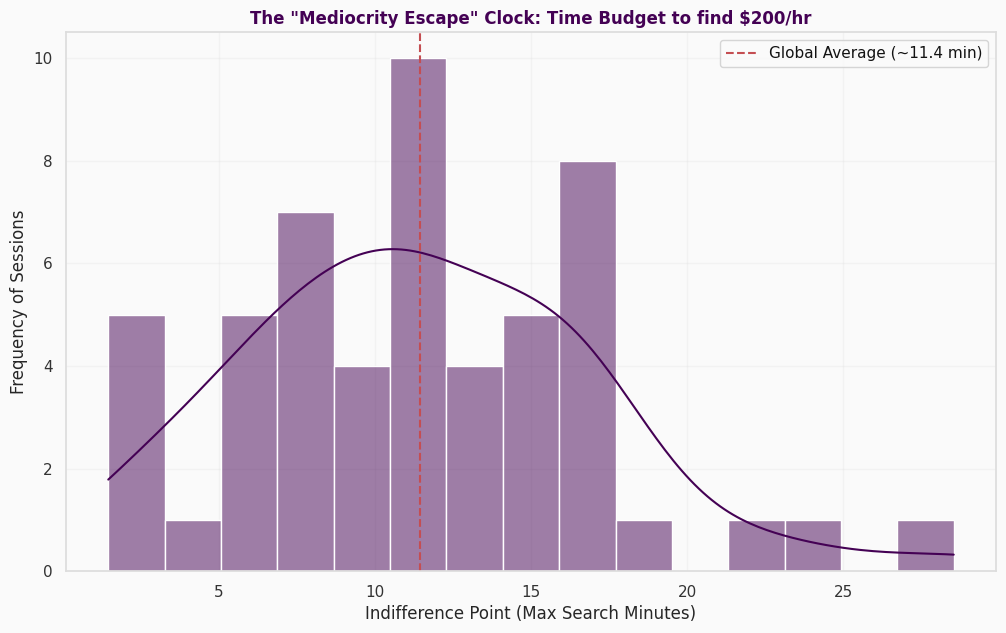


--- TOP 10 SESSIONS BY DECISION VOLUME (PATIENCE POTENTIAL) ---


,session_id,escape_clock_min,decision_volume,session_rhythm_sec
28,SID0032,28.5 min,114 offers,15.0s
24,SID0028,16.7 min,67 offers,15.0s
1,SID0002,17.1 min,64 offers,16.0s
27,SID0031,17.3 min,61 offers,17.0s
45,SID0054,21.5 min,56 offers,23.0s
41,SID0049,13.8 min,55 offers,15.0s
39,SID0047,14.4 min,54 offers,16.0s
21,SID0025,17.8 min,53 offers,20.0s
40,SID0048,16.6 min,52 offers,19.0s
9,SID0011,23.2 min,52 offers,27.0s


In [ ]:
# ==============================================================================
# CELL 2.1: EL PUNTO DE ESCAPE (MEDIOCRIDAD vs. SUFICIENCIA) - REFACTORED
# ==============================================================================
# Purpose: Calculate the Indifference Point for escaping \$150/hr offers,
#          integrated with the sanitized search rhythm logic.
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 2.1: CALCULATING THE ESCAPE CLOCK (150 vs 200) ---")

    # 1. DEFINITION OF THRESHOLDS (The "Escape" Scenario)
    EPH_MEDIOCRE = 150.0
    EPH_SUFICIENTE = 200.0

    # We use the median search rhythm we calculated in Cell 1.8 for context
    # (Assuming rhythm_P50_median_sec exists from the previous merge)

    escape_points = []

    # 2. ITERATION BY SESSION (Unified Market Approach)
    for session_id, df_session in df_opportunity_cost.groupby('session_fk'):

        # 2.1. CONSTRUCT ARCHETYPES FOR THIS SESSION
        props_mediocre = df_session[
            df_session['eph_real'].between(EPH_MEDIOCRE - 15, EPH_MEDIOCRE + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_suficiente = df_session[
            df_session['eph_real'].between(EPH_SUFICIENTE - 15, EPH_SUFICIENTE + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        # Skip sessions without enough variety to form both archetypes
        if props_mediocre.isnull().any() or props_suficiente.isnull().any():
            continue

        # 2.2. BASELINE EPH (The "Bird in Hand")
        eph_mediocre_base = (props_mediocre['upfront_fare'] /
                             (props_mediocre['time_to_pickup_sec'] + props_mediocre['est_trip_time_sec'])) * 3600

        # 2.3. ALGEBRAIC INDIFFERENCE POINT
        if eph_mediocre_base > 0:
            # Formula: (Fare_target * 3600 / EPH_baseline) - Total_Time_target
            t_max_sec = ( (props_suficiente['upfront_fare'] * 3600) / eph_mediocre_base ) - \
                        (props_suficiente['time_to_pickup_sec'] + props_suficiente['est_trip_time_sec'])

            t_max_min = t_max_sec / 60.0

            if t_max_min > 0:
                # Calculate "Decision Volume": How many offers fit in this search window?
                session_rhythm = df_session['sanitized_search_delta'].median()
                decision_volume = (t_max_sec / session_rhythm) if session_rhythm > 0 else np.nan

                escape_points.append({
                    'session_id': session_id,
                    'escape_clock_min': t_max_min,
                    'decision_volume': decision_volume,
                    'session_rhythm_sec': session_rhythm
                })

    df_escape = pd.DataFrame(escape_points)

    # 3. ANALYSIS & VISUALIZATION
    if not df_escape.empty:
        avg_clock = df_escape['escape_clock_min'].mean()
        avg_volume = df_escape['decision_volume'].mean()

        print(f"📈 Global Escape Clock (Mean): {avg_clock:.2f} minutes")
        print(f"📈 Average Decision Volume: {avg_volume:.1f} offers")

        plt.figure(figsize=(12, 7))
        sns.histplot(df_escape['escape_clock_min'], bins=15, kde=True, color=OPUS_PURPLE)

        plt.axvline(x=avg_clock, color='r', linestyle='--',
                    label=f'Global Average (~{avg_clock:.1f} min)')

        plt.title('The "Mediocrity Escape" Clock: Time Budget to find $200/hr', color=OPUS_PURPLE)
        plt.xlabel('Indifference Point (Max Search Minutes)')
        plt.ylabel('Frequency of Sessions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Summary Table for the "Decision Volume" insight
        print("\n--- TOP 10 SESSIONS BY DECISION VOLUME (PATIENCE POTENTIAL) ---")
        display(df_escape.sort_values('decision_volume', ascending=False).head(10).style.format({
            'escape_clock_min': '{:.1f} min',
            'decision_volume': '{:.0f} offers',
            'session_rhythm_sec': '{:.1f}s'
        }))

    else:
        print("🔴 Critical: Not enough data to calculate Escape Points. Check EPH ranges.")

else:
    print("🔴 Dataframe df_opportunity_cost not found.")

In [ ]:
# ==============================================================================
# CELL 3: INVESTIGACIÓN 2 - EL ORÁCULO DE LA OPORTUNIDAD (150 vs 200)
# ==============================================================================
# Purpose: Calculate the empirical probability of finding "Mediocre" ($150)
#          and "Sufficient" ($200) offers using a Tier-Agnostic Global Baseline.
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.0: AUDITING THE GLOBAL FUTURE (TIER-AGNOSTIC: 150 vs 200) ---")

    # 1. PREPARE DATASET (Sorted by time)
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()

    # 2. DEFINE GLOBAL SUCCESS FLAGS
    # 150 = Mediocre / "Better than nothing"
    # 200 = Sufficient / "The Target"
    df_prob['is_mediocre_target']   = (df_prob['eph_real'] >= 150).astype(int)
    df_prob['is_sufficient_target'] = (df_prob['eph_real'] >= 200).astype(int)

    # 3. SET TIME WINDOWS (Discovery from Inv 1)
    # 210s = 3.5m (The tight Gem Hunting budget)
    # 684s = 11.4m (The generous Mediocrity Escape budget)
    windows = {
        'Gem Budget (3.5m)': '210s',
        'Escape Budget (11.4m)': '684s'
    }

    # 4. VECTORIZED LOOK-AHEAD
    df_prob = df_prob.set_index('offer_timestamp')
    df_reversed = df_prob.iloc[::-1] # Reverse to look "forward" using rolling

    oracle_results = []

    for label, window_size in windows.items():
        # Probability of finding at least one MEDIOCRE offer (>= 150)
        found_mediocre = df_reversed['is_mediocre_target'].rolling(window=window_size).max().iloc[::-1]

        # Probability of finding at least one SUFFICIENT offer (>= 200)
        found_sufficient = df_reversed['is_sufficient_target'].rolling(window=window_size).max().iloc[::-1]

        oracle_results.append({
            'Window': label,
            'Prob. of Mediocre (>$150)': found_mediocre.mean(),
            'Prob. of Sufficient (>$200)': found_sufficient.mean()
        })

    # 5. PRESENTATION
    df_final_oracle = pd.DataFrame(oracle_results)

    print("\n## 🎲 THE GLOBAL ORACLE: Success Probabilities (150 vs 200)")
    display(df_final_oracle.style.format({
        'Prob. of Mediocre (>$150)': '{:.1%}',
        'Prob. of Sufficient (>$200)': '{:.1%}'
    }).background_gradient(cmap='Purples'))

else:
    print("🔴 Error: df_opportunity_cost not loaded.")

--- 3.0: AUDITING THE GLOBAL FUTURE (TIER-AGNOSTIC: 150 vs 200) ---

## 🎲 THE GLOBAL ORACLE: Success Probabilities (150 vs 200)


,Window,Prob. of Mediocre (>$150),Prob. of Sufficient (>$200)
0,Gem Budget (3.5m),99.3%,85.7%
1,Escape Budget (11.4m),99.6%,92.0%


--- 3.0: CONSTRUCTING THE STRATEGIC HEATMAP ---
⏳ Auditing future possibilities across quadrants...


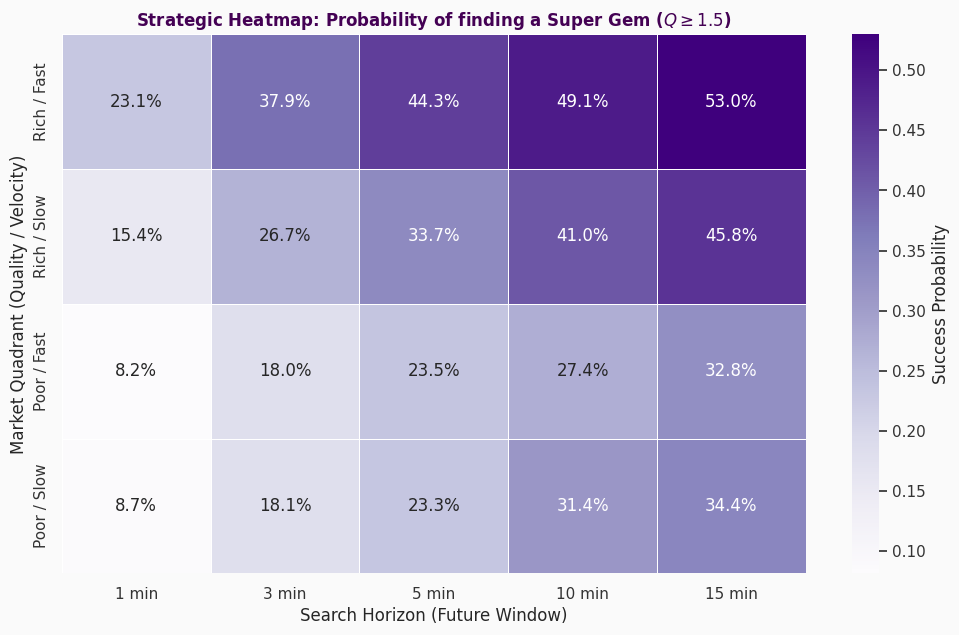


## 🎲 Strategic Probability Matrix


Window,1 min,3 min,5 min,10 min,15 min
Quadrant,,,,,
Rich / Fast,23.1%,37.9%,44.3%,49.1%,53.0%
Rich / Slow,15.4%,26.7%,33.7%,41.0%,45.8%
Poor / Fast,8.2%,18.0%,23.5%,27.4%,32.8%
Poor / Slow,8.7%,18.1%,23.3%,31.4%,34.4%


In [ ]:
# ==============================================================================
# CELL 3 (v2.1): THE STRATEGIC PROBABILITY MATRIX (FIXED)
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.0: CONSTRUCTING THE STRATEGIC HEATMAP ---")

    # 1. AXIS 1: QUALITY (Rich vs. Poor)
    session_mqi = df_opportunity_cost.groupby('session_fk')['offer_quality_index'].mean().to_dict()
    df_opportunity_cost['session_mqi'] = df_opportunity_cost['session_fk'].map(session_mqi)
    df_opportunity_cost['quality_state'] = df_opportunity_cost['session_mqi'].apply(
        lambda x: 'Rich' if x >= 1.0 else 'Poor'
    )

    # 2. AXIS 2: VELOCITY (Fast vs. Slow)
    global_median_rhythm = df_opportunity_cost['sanitized_search_delta'].median()
    session_rhythm = df_opportunity_cost.groupby('session_fk')['sanitized_search_delta'].median().to_dict()
    df_opportunity_cost['session_rhythm'] = df_opportunity_cost['session_fk'].map(session_rhythm)

    df_opportunity_cost['velocity_state'] = df_opportunity_cost['session_rhythm'].apply(
        lambda x: 'Fast' if x <= global_median_rhythm else 'Slow'
    )

    # 3. CREATE THE STRATEGIC QUADRANT
    df_opportunity_cost['quadrant'] = df_opportunity_cost['quality_state'] + ' / ' + df_opportunity_cost['velocity_state']

    # 4. VECTORIZED PROBABILITY AUDIT
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()
    df_prob['is_super_gem'] = (df_prob['offer_quality_index'] >= 1.5).astype(int)
    df_prob = df_prob.set_index('offer_timestamp')
    df_reversed = df_prob.iloc[::-1]

    time_windows = {
        '1 min': '60s',
        '3 min': '180s',
        '5 min': '300s',
        '10 min': '600s',
        '15 min': '900s'
    }

    print("⏳ Auditing future possibilities across quadrants...")

    quadrant_probs = []
    for label, delta in time_windows.items():
        # Rolling window looking forward
        found_gem = df_reversed['is_super_gem'].rolling(window=delta).max().iloc[::-1]

        # Group by quadrant and calculate success rate
        probs = found_gem.groupby(df_prob['quadrant']).mean()
        for quad, p in probs.items():
            quadrant_probs.append({'Quadrant': quad, 'Window': label, 'Probability': p})

    # 5. MATRIX GENERATION
    prob_matrix = pd.DataFrame(quadrant_probs).pivot(index='Quadrant', columns='Window', values='Probability')

    ordered_idx = ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']
    prob_matrix = prob_matrix.reindex([i for i in ordered_idx if i in prob_matrix.index])
    prob_matrix = prob_matrix[['1 min', '3 min', '5 min', '10 min', '15 min']]

    # 6. VISUALIZATION
    plt.figure(figsize=(12, 7))
    # Note: Use raw string r"" and \geq for Matplotlib math
    sns.heatmap(prob_matrix, annot=True, fmt=".1%", cmap="Purples", linewidths=.5, cbar_kws={'label': 'Success Probability'})

    plt.title(r'Strategic Heatmap: Probability of finding a Super Gem ($Q \geq 1.5$)', color=OPUS_PURPLE)
    plt.xlabel('Search Horizon (Future Window)')
    plt.ylabel('Market Quadrant (Quality / Velocity)')
    plt.show()

    print("\n## 🎲 Strategic Probability Matrix")
    display(prob_matrix.style.format('{:.1%}')
                             .background_gradient(cmap='Purples', axis=None))

else:
    print("🔴 Dataframe df_opportunity_cost not found.")

window,1m,3m,5m,10m,15m
quadrant,,,,,
Rich / Fast,85.0%,92.1%,94.7%,95.9%,96.0%
Rich / Slow,73.1%,85.5%,88.5%,90.6%,90.8%
Poor / Fast,54.6%,75.0%,82.0%,87.2%,87.9%
Poor / Slow,57.3%,78.4%,85.8%,93.9%,93.9%



## ♟️ Playbook: Net Expected Value (VEN) of waiting for $200/hr


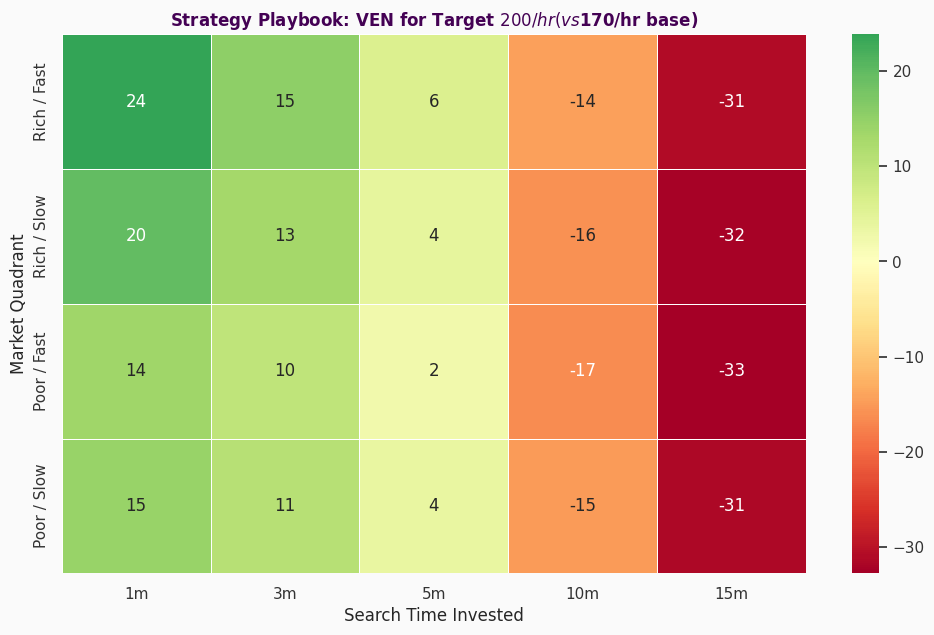

Enter Target EPH (e.g., 230) or 'exit': exit


In [ ]:
# ==============================================================================
# CELL 3 (v3.2): THE PIENZA STRATEGY SIMULATOR (NET EXPECTED VALUE)
# ==============================================================================
# Purpose: prescriptive analysis to determine if searching for a specific EPH
#          is a winning or losing bet based on market quadrants.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, clear_output

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    def simulate_strategy(target_eph):
        clear_output(wait=True)
        print(f"--- 🎲 PIENZA STRATEGY SIMULATOR ---")
        print(f"Analyzing scenarios for Target EPH: ${target_eph}/hr\n")

        # 1. ARCHETYPE CONSTRUCTION
        # Baseline (What you have now): Target - $30 (e.g. if you want 230, you have 200)
        baseline_eph = target_eph - 30

        props_base = df_opportunity_cost[df_opportunity_cost['eph_real'].between(baseline_eph - 15, baseline_eph + 15)][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()
        props_target = df_opportunity_cost[df_opportunity_cost['eph_real'].between(target_eph - 15, target_eph + 15)][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_target.isnull().any():
            print(f"⚠️ Data scarcity for archetype ${target_eph}. Try a value between 150 and 280.")
            return

        # 2. VECTORIZED ORACLE (Probability of finding target_eph)
        df_sim = df_opportunity_cost.sort_values('offer_timestamp').copy()
        df_sim['is_success'] = (df_sim['eph_real'] >= target_eph).astype(int)
        df_sim = df_sim.set_index('offer_timestamp')
        df_reversed = df_sim.iloc[::-1]

        time_windows = {'1m': '60s', '3m': '180s', '5m': '300s', '10m': '600s', '15m': '900s'}

        # Audit futures
        prob_results = []
        for label, delta in time_windows.items():
            found_success = df_reversed['is_success'].rolling(window=delta).max().iloc[::-1]
            probs = found_success.groupby(df_sim['quadrant']).mean()
            for quad, p in probs.items():
                prob_results.append({'quadrant': quad, 'window': label, 'prob': p, 'window_sec': int(delta[:-1])})

        res_df = pd.DataFrame(prob_results)

        # 3. SYNTHESIS: NET EXPECTED VALUE (VEN)
        # Constant baseline EPH (Immediate acceptance)
        eph_base_immediate = (props_base['upfront_fare'] / (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        def calculate_ven(row):
            # Scenario A: Success (You find the Target)
            cycle_success = row['window_sec'] + props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec']
            eph_success = (props_target['upfront_fare'] / cycle_success) * 3600

            # Scenario B: Failure (You give up and take the baseline after waiting)
            cycle_failure = row['window_sec'] + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
            eph_failure = (props_base['upfront_fare'] / cycle_failure) * 3600

            # Expected Value of the search
            ev_wait = (row['prob'] * eph_success) + ((1 - row['prob']) * eph_failure)
            return ev_wait - eph_base_immediate

        res_df['ven'] = res_df.apply(calculate_ven, axis=1)

        # 4. MATRICES
        ven_matrix = res_df.pivot(index='quadrant', columns='window', values='ven')
        ven_matrix = ven_matrix[['1m', '3m', '5m', '10m', '15m']]

        prob_matrix = res_df.pivot(index='quadrant', columns='window', values='prob')
        prob_matrix = prob_matrix[['1m', '3m', '5m', '10m', '15m']]

        # Order quadrants
        q_order = ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']
        ven_matrix = ven_matrix.reindex([q for q in q_order if q in ven_matrix.index])
        prob_matrix = prob_matrix.reindex([q for q in q_order if q in prob_matrix.index])

        # 5. VISUALIZATION
        print(f"## 🎲 Oracle: Probability of finding >= ${target_eph}/hr")
        display(prob_matrix.style.format('{:.1%}').background_gradient(cmap='Greens'))

        print(f"\n## ♟️ Playbook: Net Expected Value (VEN) of waiting for ${target_eph}/hr")
        plt.figure(figsize=(12, 7))
        sns.heatmap(ven_matrix, annot=True, fmt=".0f", cmap="RdYlGn", center=0, linewidths=.5)
        plt.title(f'Strategy Playbook: VEN for Target ${target_eph}/hr (vs ${baseline_eph:.0f}/hr base)', color=OPUS_PURPLE)
        plt.xlabel('Search Time Invested')
        plt.ylabel('Market Quadrant')
        plt.show()

    # --- INTERACTIVE LOOP ---
    while True:
        try:
            val = input("Enter Target EPH (e.g., 230) or 'exit': ")
            if val.lower() in ['exit', 'salir']: break
            simulate_strategy(int(val))
        except Exception as e:
            print(f"Error: {e}")
            break
else:
    print("🔴 Dataframe not found.")

--- 4.0: GENERATING FINAL FRONTIER (TEAL/PURPLE | LIMIT 9m) ---


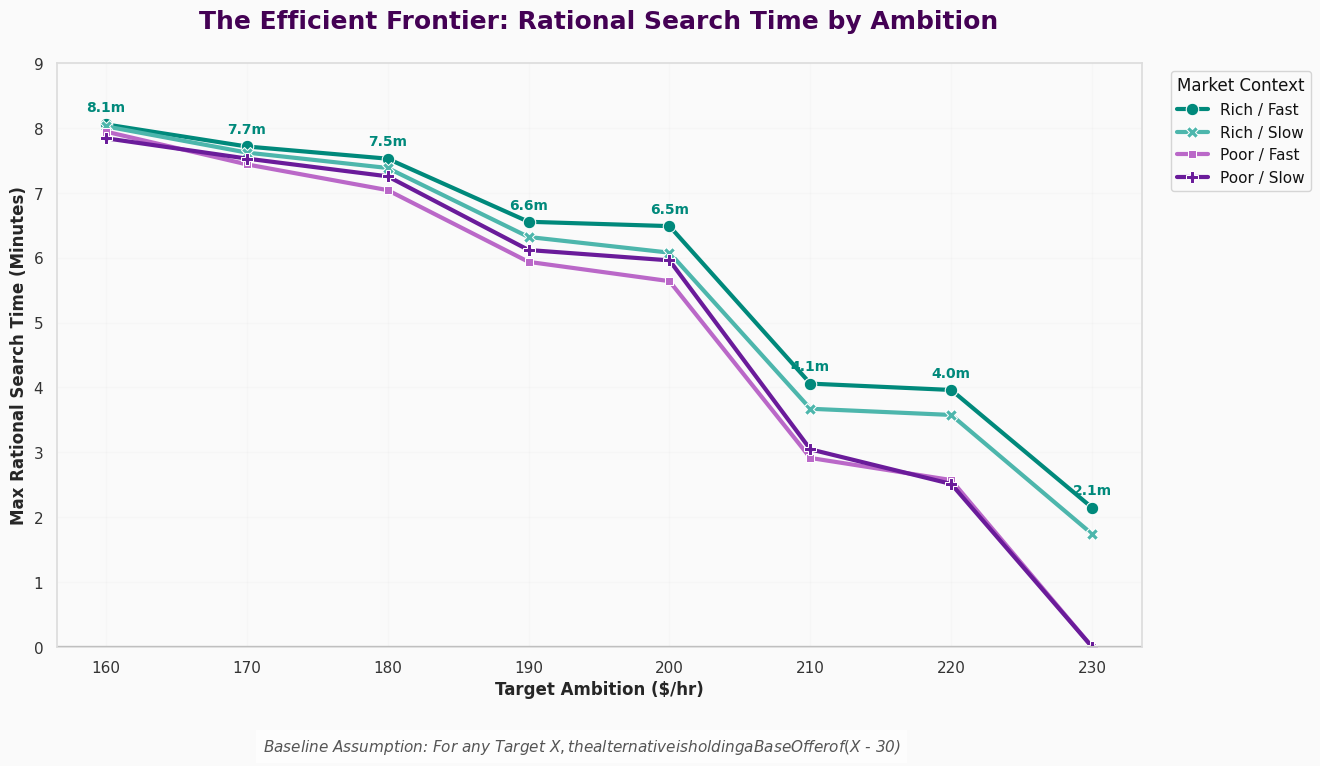

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ==============================================================================
# CELL 4 (FINAL REFINEMENT): PURPLE/TEAL PALETTE & 9-MIN LIMIT
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 4.0: GENERATING FINAL FRONTIER (TEAL/PURPLE | LIMIT 9m) ---")

    # 1. SETUP PARAMETERS (Range 160 to 230)
    target_range = range(160, 240, 10) # 240 is exclusive, so it stops at 230

    # Time windows map
    windows_min = [1, 3, 5, 10, 15]
    windows_sec = [60, 180, 300, 600, 900]
    windows_map = dict(zip(windows_min, windows_sec))

    frontier_data = []

    # 2. ITERATIVE SIMULATION
    for target_eph in target_range:
        baseline_eph = target_eph - 30

        # Archetypes
        props_base = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(baseline_eph - 15, baseline_eph + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_target = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(target_eph - 15, target_eph + 15)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_target.isnull().any():
            continue

        eph_base_immediate = (props_base['upfront_fare'] /
                              (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        # Simulation
        df_sim = df_opportunity_cost.sort_values('offer_timestamp').copy()
        df_sim['is_success'] = (df_sim['eph_real'] >= target_eph).astype(int)
        df_sim = df_sim.set_index('offer_timestamp')
        df_reversed = df_sim.iloc[::-1]

        quadrant_vens = {q: [] for q in ['Rich / Fast', 'Rich / Slow', 'Poor / Fast', 'Poor / Slow']}

        for w_min, w_sec in windows_map.items():
            window_str = f"{w_sec}s"
            found_success = df_reversed['is_success'].rolling(window=window_str).max().iloc[::-1]
            probs = found_success.groupby(df_sim['quadrant']).mean()

            for quad in quadrant_vens.keys():
                if quad in probs:
                    prob = probs[quad]
                    cycle_success = w_sec + props_target['time_to_pickup_sec'] + props_target['est_trip_time_sec']
                    eph_success = (props_target['upfront_fare'] / cycle_success) * 3600
                    cycle_failure = w_sec + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
                    eph_failure = (props_base['upfront_fare'] / cycle_failure) * 3600

                    ev_wait = (prob * eph_success) + ((1 - prob) * eph_failure)
                    ven = ev_wait - eph_base_immediate
                    quadrant_vens[quad].append(ven)
                else:
                    quadrant_vens[quad].append(np.nan)

        # Interpolation
        for quad, vens in quadrant_vens.items():
            valid_indices = [i for i, v in enumerate(vens) if not np.isnan(v)]
            if len(valid_indices) < 2: continue

            x_vals = [windows_min[i] for i in valid_indices]
            y_vals = [vens[i] for i in valid_indices]

            if y_vals[0] < 0:
                break_even_time = 0
            elif all(y > 0 for y in y_vals):
                break_even_time = 15.2
            else:
                f = interp1d(y_vals, x_vals, kind='linear', fill_value="extrapolate")
                break_even_time = float(f(0))
                break_even_time = max(0, min(break_even_time, 15.5))

            frontier_data.append({
                'Target EPH': target_eph,
                'Quadrant': quad,
                'Max Wait Time (Minutes)': break_even_time
            })

    # 3. VISUALIZATION
    df_frontier = pd.DataFrame(frontier_data)

    plt.figure(figsize=(14, 8))

    # Custom Palette: TEAL (Good) -> PURPLE (Bad)
    teal_purple_palette = {
        'Rich / Fast': '#00897B',  # Strong Teal (Best Case)
        'Rich / Slow': '#4DB6AC',  # Soft Teal
        'Poor / Fast': '#BA68C8',  # Soft Purple
        'Poor / Slow': '#6A1B9A'   # Deep Purple (Worst Case)
    }

    ax = sns.lineplot(
        data=df_frontier,
        x='Target EPH',
        y='Max Wait Time (Minutes)',
        hue='Quadrant',
        palette=teal_purple_palette,
        style='Quadrant',
        markers=True,
        dashes=False,
        linewidth=3,
        markersize=9
    )

    # 4. AESTHETICS & LIMITS
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
    plt.ylim(0, 9) # Capped at 9 minutes as requested

    # 5. LABELS (Rich/Fast Only)
    # Filter for just the top line to annotate
    rich_fast_points = df_frontier[df_frontier['Quadrant'] == 'Rich / Fast']

    for idx, row in rich_fast_points.iterrows():
        plt.text(
            x=row['Target EPH'],
            y=row['Max Wait Time (Minutes)'] + 0.2, # Slight offset upwards
            s=f"{row['Max Wait Time (Minutes)']:.1f}m",
            color=teal_purple_palette['Rich / Fast'],
            fontsize=10,
            fontweight='bold',
            ha='center'
        )

    # 6. TITLES & LEGENDS
    plt.title('The Efficient Frontier: Rational Search Time by Ambition',
              fontsize=18, fontweight='bold', color='#440154', pad=25)

    # Bottom Legend/Subtitle
    plt.figtext(0.5, 0.02,
                "Baseline Assumption: For any Target $X, the alternative is holding a Base Offer of ($X - 30)",
                ha="center", fontsize=11, style='italic', color='#555555',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

    plt.xlabel('Target Ambition ($/hr)', fontsize=12, fontweight='bold')
    plt.ylabel('Max Rational Search Time (Minutes)', fontsize=12, fontweight='bold')
    plt.xticks(target_range)
    plt.grid(True, alpha=0.15)

    plt.legend(title='Market Context', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    # Adjust layout to make room for bottom text
    plt.subplots_adjust(bottom=0.15)

    plt.show()

else:
    print("🔴 Run previous cells to load data first.")

--- 3.1: ANALYZING BEHAVIORAL SUPPLY ELASTICITY (ZOOMED) ---


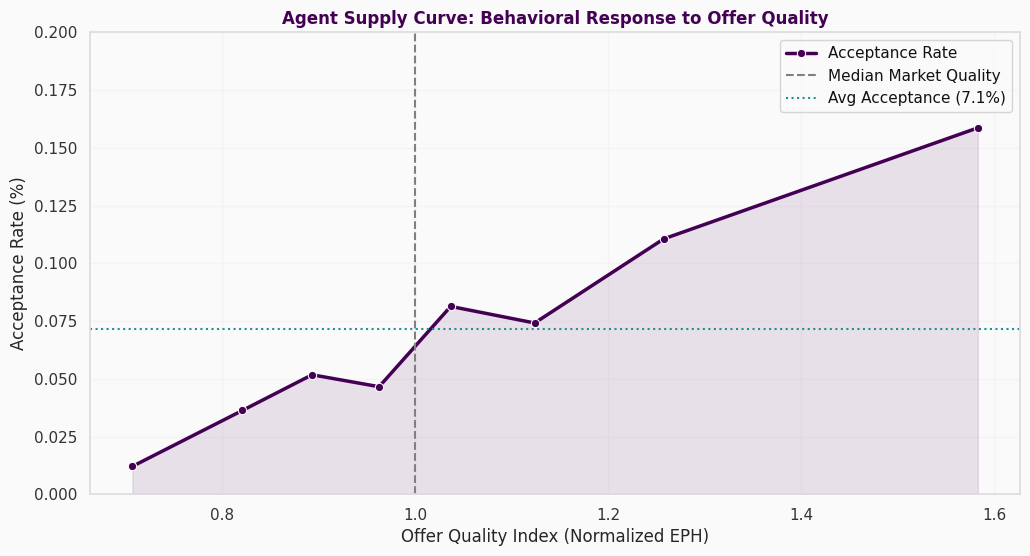

,quality_bin,avg_quality_index,acceptance_rate,offer_count,elasticity
0,0,0.71,1.2%,580,nan
1,1,0.82,3.6%,579,12.44
2,2,0.89,5.2%,580,4.84
3,3,0.96,4.7%,580,-1.29
4,4,1.04,8.1%,578,9.69
5,5,1.12,7.4%,580,-1.05
6,6,1.26,11.1%,579,4.13
7,7,1.58,15.9%,580,1.68


In [ ]:
# ==============================================================================
# CELL 3.1 (REVISED): AGENT SUPPLY ELASTICITY - THE BEHAVIORAL RESPONSE
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 3.1: ANALYZING BEHAVIORAL SUPPLY ELASTICITY (ZOOMED) ---")

    # 1. INSPECT THE DATA
    actual_actions = df_opportunity_cost['offer_action'].unique()
    # print(f"🔍 Found Actions in Database: {actual_actions}")

    df_el = df_opportunity_cost.copy()

    # 2. ROBUST ACCEPTANCE IDENTIFICATION
    df_el['was_accepted'] = df_el['offer_action'].astype(str).str.upper().str.contains('ACCEPT').astype(int)

    # 3. CREATE QUALITY DECILES (8 Bins)
    df_el['quality_bin'] = pd.qcut(df_el['offer_quality_index'], 8, labels=False, duplicates='drop')

    # 4. CALCULATE THE SUPPLY CURVE
    supply_curve = df_el.groupby('quality_bin').agg(
        avg_quality_index=('offer_quality_index', 'mean'),
        acceptance_rate=('was_accepted', 'mean'),
        offer_count=('offer_id', 'count')
    ).reset_index()

    # 5. CALCULATE ELASTICITY
    supply_curve['elasticity'] = (supply_curve['acceptance_rate'].pct_change() /
                                  supply_curve['avg_quality_index'].pct_change())

    # 6. VISUALIZATION
    plt.figure(figsize=(12, 6))

    # Main Supply Curve
    sns.lineplot(x='avg_quality_index', y='acceptance_rate', data=supply_curve,
                 marker='o', color=OPUS_PURPLE, linewidth=2.5, label='Acceptance Rate')

    # Fill under the curve
    plt.fill_between(supply_curve['avg_quality_index'], supply_curve['acceptance_rate'],
                     color=OPUS_PURPLE, alpha=0.1)

    # Threshold markers
    plt.axvline(1.0, color='gray', linestyle='--', label='Median Market Quality')
    plt.axhline(df_el['was_accepted'].mean(), color=OPUS_TEAL, linestyle=':',
                label=f'Avg Acceptance ({df_el["was_accepted"].mean():.1%})')

    plt.title('Agent Supply Curve: Behavioral Response to Offer Quality', color=OPUS_PURPLE)
    plt.xlabel('Offer Quality Index (Normalized EPH)')
    plt.ylabel('Acceptance Rate (%)')

    # --- ADJUSTED Y-AXIS LIMIT ---
    plt.ylim(0, 0.20)
    # -----------------------------

    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    display(supply_curve.style.format({
        'avg_quality_index': '{:.2f}',
        'acceptance_rate': '{:.1%}',
        'elasticity': '{:.2f}'
    }))

else:
    print("🔴 Error: df_opportunity_cost not loaded.")